# 🚀 AI Resume-Job Matcher - IMPROVED VERSION

## Features Added:
1. **Skill Matching**: Explicit tech and soft skill detection
2. **Keyword Overlap**: Direct keyword matching between resume and job
3. **Education Matching**: Degree level verification
4. **Experience Extraction**: Years of experience detection
5. **Industry Detection**: Field-specific keyword groups
6. **Enhanced TF-IDF**: Combined with rule-based features

## Expected Improvements:
- Better discrimination between good and bad matches
- Scores spanning full 0-100 range
- Chef resume should score <30, Tech resume should score >80

In [1]:
# Install required packages
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn nltk sentence-transformers


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
print("🔧 Loading dataset with auto-detection...")

# Try different encodings AND separators
encodings_to_try = ['utf-8-sig', 'utf-8', 'latin-1', 'cp1252']
separators_to_try = [',', ';', '|', '\t']

df = None
successful_config = None

for encoding in encodings_to_try:
    for sep in separators_to_try:
        try:
            test_df = pd.read_csv('resume_data.csv', 
                                encoding=encoding, 
                                sep=sep,
                                on_bad_lines='skip',
                                engine='python')
            
            # Clean column names immediately
            test_df.columns = test_df.columns.str.strip()
            test_df.columns = [col.encode('ascii', 'ignore').decode('ascii') for col in test_df.columns]
            
            # Check if we actually got meaningful data
            if len(test_df.columns) > 5:  # Should have multiple columns
                non_null_count = test_df.notna().sum().sum()
                if non_null_count > 100:  # Should have substantial data
                    df = test_df
                    successful_config = (encoding, sep)
                    print(f"✅ SUCCESS with encoding='{encoding}', separator='{sep}'")
                    print(f"   Found {non_null_count} non-null values")
                    break
                    
        except Exception as e:
            continue
    
    if df is not None:
        break

if df is None:
    raise Exception("❌ Could not load CSV file properly!")

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📋 Columns ({len(df.columns)}): {list(df.columns)}")

# Check data content
print(f"\n🔍 Data quality check:")
for col in df.columns[:5]:  # Check first 5 columns
    non_null = df[col].notna().sum()
    print(f"  {col}: {non_null}/{len(df)} non-null ({100*non_null/len(df):.1f}%)")

print(f"\n👀 First 2 rows:")
print(df.head(2))

🔧 Loading dataset with auto-detection...
✅ SUCCESS with encoding='utf-8-sig', separator=','
   Found 163092 non-null values

📊 Dataset shape: (9560, 21)
📋 Columns (21): ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'major_field_of_studies', 'professional_company_names', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'responsibilities.1', 'skills_required', 'matched_score']

🔍 Data quality check:
  career_objective: 4756/9560 non-null (49.7%)
  skills: 9486/9560 non-null (99.2%)
  educational_institution_name: 9458/9560 non-null (98.9%)
  degree_names: 9458/9560 non-null (98.9%)
  passing_years: 9458/9560 non-null (98.9%)

👀 First 2 rows:
                 career_objective skills educational_institution_name  \
0  Cross-Functional Collaboration   None         

In [4]:
print("\n" + "="*60)
print("COLUMN ANALYSIS AND DROPPING")
print("="*60)

# Calculate missing percentages
print("\n🔍 Analyzing columns:")

missing_info = []
for col in df.columns:
    total = len(df)
    null_count = df[col].isnull().sum()
    
    # Also check for empty strings and 'N/A'
    if df[col].dtype == 'object':
        empty_count = ((df[col] == '') | (df[col] == 'N/A')).sum()
    else:
        empty_count = 0
    
    total_missing = null_count + empty_count
    missing_pct = (total_missing / total) * 100
    valid_count = total - total_missing
    
    missing_info.append({
        'column': col,
        'missing_pct': missing_pct,
        'valid_count': valid_count
    })
    
    # Only print if has significant data or missing
    if missing_pct > 0 or valid_count > 0:
        print(f"  {col}: {valid_count}/{total} valid ({100-missing_pct:.1f}%)")

print("\n" + "-"*60)

# Drop columns with >40% missing (but keep matched_score)
threshold = 40
cols_to_drop = []

for info in missing_info:
    if info['missing_pct'] > threshold:
        # Always keep the target variable
        if info['column'] != 'matched_score':
            cols_to_drop.append(info['column'])

if cols_to_drop:
    print(f"\n🗑️ Dropping {len(cols_to_drop)} columns with >{threshold}% missing:")
    for col in cols_to_drop:
        pct = next(x['missing_pct'] for x in missing_info if x['column'] == col)
        print(f"   - {col} ({pct:.1f}% missing)")
    
    df = df.drop(columns=cols_to_drop)
    print(f"\n✅ Dropped {len(cols_to_drop)} columns")
else:
    print(f"\n✅ No columns dropped - all have sufficient data!")

# Drop irrelevant columns
irrelevant_cols = [
    'online_links', 'issue_dates', 'expiry_dates', 
    'passing_years', 'positions', 'locations'
]

cols_to_remove = [col for col in irrelevant_cols if col in df.columns]
if cols_to_remove:
    print(f"\n🗑️ Dropping {len(cols_to_remove)} irrelevant columns:")
    for col in cols_to_remove:
        print(f"   - {col}")
    df = df.drop(columns=cols_to_remove)

print(f"\n✅ Final dataset shape: {df.shape}")
print(f"✅ Remaining columns ({len(df.columns)}): {list(df.columns)}")

# Final validation
if df.shape[1] == 0:
    raise Exception("❌ ERROR: All columns dropped! Your CSV might be corrupted.")

if df.shape[0] == 0:
    raise Exception("❌ ERROR: No rows remaining!")

# Show sample
print(f"\n📄 Sample of final data:")
pd.set_option('display.max_columns', None)
print(df.head(2))


COLUMN ANALYSIS AND DROPPING

🔍 Analyzing columns:
  career_objective: 4756/9560 valid (49.7%)
  skills: 9486/9560 valid (99.2%)
  educational_institution_name: 9458/9560 valid (98.9%)
  degree_names: 9458/9560 valid (98.9%)
  passing_years: 9458/9560 valid (98.9%)
  major_field_of_studies: 9459/9560 valid (98.9%)
  professional_company_names: 9459/9560 valid (98.9%)
  related_skils_in_job: 9459/9560 valid (98.9%)
  positions: 9459/9560 valid (98.9%)
  locations: 9458/9560 valid (98.9%)
  responsibilities: 9543/9560 valid (99.8%)
  extra_curricular_activity_types: 3426/9560 valid (35.8%)
  online_links: 2008/9560 valid (21.0%)
  issue_dates: 2008/9560 valid (21.0%)
  expiry_dates: 2008/9560 valid (21.0%)
  job_position_name: 9542/9560 valid (99.8%)
  educationaL_requirements: 9542/9560 valid (99.8%)
  experiencere_requirement: 8178/9560 valid (85.5%)
  responsibilities.1: 9542/9560 valid (99.8%)
  skills_required: 7843/9560 valid (82.0%)
  matched_score: 9542/9560 valid (99.8%)

-----

In [5]:
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text) or text == '' or text == 'N/A':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

print("✅ Text cleaning function defined")

✅ Text cleaning function defined


In [6]:
print("\n" + "="*60)
print("TEXT PREPROCESSING")
print("="*60)

# Get all text columns (exclude target)
text_columns = df.select_dtypes(include=['object']).columns.tolist()
if 'matched_score' in text_columns:
    text_columns.remove('matched_score')

print(f"🔄 Processing {len(text_columns)} text columns...")

for col in text_columns:
    print(f"  Cleaning: {col}")
    df[col] = df[col].apply(clean_text)

print("\n✅ Text preprocessing complete")


TEXT PREPROCESSING
🔄 Processing 12 text columns...
  Cleaning: skills
  Cleaning: educational_institution_name
  Cleaning: degree_names
  Cleaning: major_field_of_studies
  Cleaning: professional_company_names
  Cleaning: related_skils_in_job
  Cleaning: responsibilities
  Cleaning: job_position_name
  Cleaning: educationaL_requirements
  Cleaning: experiencere_requirement
  Cleaning: responsibilities.1
  Cleaning: skills_required

✅ Text preprocessing complete


In [7]:
print("\n" + "="*60)
print("CREATING COMBINED TEXT FEATURES")
print("="*60)

# Define expected column groups
resume_cols = [
    'career_objective', 'skills', 'educational_institution_name',
    'degree_names', 'major_field_of_studies', 'professional_company_names',
    'related_skils_in_job', 'responsibilities'
]

job_cols = [
    'job_position_name', 'educational_requirements', 
    'experiencere_requirement', 'responsibilities.1', 'skills_required'
]

# Filter to only existing columns
resume_cols = [col for col in resume_cols if col in df.columns]
job_cols = [col for col in job_cols if col in df.columns]

print(f"📋 Resume columns found: {len(resume_cols)}")
print(f"📋 Job columns found: {len(job_cols)}")

# If no expected columns found, split available text columns
if len(resume_cols) == 0 and len(job_cols) == 0:
    print("⚠️ No expected columns found. Splitting available columns...")
    available = [col for col in df.columns if col != 'matched_score']
    mid = len(available) // 2
    resume_cols = available[:mid]
    job_cols = available[mid:]
    print(f"Using {len(resume_cols)} columns for resume, {len(job_cols)} for job")

# Combine text
if resume_cols:
    df['resume_text'] = df[resume_cols].fillna('').astype(str).agg(' '.join, axis=1)
    df['resume_text'] = df['resume_text'].apply(clean_text)
else:
    df['resume_text'] = ''

if job_cols:
    df['job_text'] = df[job_cols].fillna('').astype(str).agg(' '.join, axis=1)
    df['job_text'] = df['job_text'].apply(clean_text)
else:
    df['job_text'] = ''

# Remove rows with very short text (< 10 characters)
initial_len = len(df)
df = df[(df['resume_text'].apply(len) > 10) & (df['job_text'].apply(len) > 10)]
final_len = len(df)

print(f"\n✅ Combined text features created")
print(f"📊 Rows removed (insufficient text): {initial_len - final_len}")
print(f"📊 Final dataset shape: {df.shape}")

if len(df) > 0:
    print(f"📏 Average resume length: {df['resume_text'].apply(len).mean():.0f} chars")
    print(f"📏 Average job length: {df['job_text'].apply(len).mean():.0f} chars")
else:
    raise Exception("❌ No data remaining after filtering! Check your CSV file.")


CREATING COMBINED TEXT FEATURES
📋 Resume columns found: 7
📋 Job columns found: 4

✅ Combined text features created
📊 Rows removed (insufficient text): 18
📊 Final dataset shape: (9542, 15)
📏 Average resume length: 797 chars
📏 Average job length: 310 chars


# 🆕 NEW FEATURE EXTRACTION FUNCTIONS

These functions add advanced matching capabilities beyond basic TF-IDF

In [8]:
print("\n" + "="*60)
print("🆕 DEFINING SKILL MATCHING FUNCTIONS")
print("="*60)

# Define skill categories
TECH_SKILLS = [
    # Programming Languages
    'python', 'java', 'javascript', 'c++', 'c#', 'ruby', 'php', 'swift', 'kotlin',
    'typescript', 'go', 'rust', 'scala', 'r', 'matlab', 'sql',
    
    # ML/AI
    'machine learning', 'deep learning', 'neural network', 'tensorflow', 'pytorch', 
    'keras', 'scikit-learn', 'xgboost', 'nlp', 'computer vision', 'opencv',
    
    # Data Science
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'data analysis', 'statistics',
    'data visualization', 'jupyter', 'tableau', 'power bi',
    
    # Cloud & DevOps
    'aws', 'azure', 'gcp', 'google cloud', 'docker', 'kubernetes', 'jenkins',
    'ci/cd', 'terraform', 'ansible',
    
    # Web Development
    'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring', 'html',
    'css', 'rest api', 'graphql', 'microservices',
    
    # Databases
    'mysql', 'postgresql', 'mongodb', 'redis', 'elasticsearch', 'cassandra',
    'oracle', 'sql server',
    
    # Tools
    'git', 'github', 'gitlab', 'jira', 'confluence', 'linux', 'bash', 'agile', 'scrum'
]

SOFT_SKILLS = [
    'leadership', 'communication', 'teamwork', 'problem solving', 'analytical',
    'critical thinking', 'project management', 'time management', 'collaboration',
    'presentation', 'interpersonal', 'adaptability', 'creativity', 'initiative'
]

EDUCATION_KEYWORDS = {
    'phd': ['phd', 'ph.d', 'doctorate', 'doctoral'],
    'master': ['master', 'ms', 'm.s', 'msc', 'm.sc', 'mba', 'm.b.a'],
    'bachelor': ['bachelor', 'bs', 'b.s', 'bsc', 'b.sc', 'ba', 'b.a', 'bba', 'b.b.a']
}

def extract_years_experience(text):
    """Extract years of experience from text"""
    text_lower = text.lower()
    
    # Common patterns: "5 years", "5+ years", "5-7 years"
    patterns = [
        r'(\d+)\+?\s*years?',
        r'(\d+)\s*to\s*\d+\s*years?',
        r'(\d+)-\d+\s*years?'
    ]
    
    years = []
    for pattern in patterns:
        matches = re.findall(pattern, text_lower)
        years.extend([int(m) for m in matches])
    
    return max(years) if years else 0

def detect_education_level(text):
    """Detect highest education level in text"""
    text_lower = text.lower()
    
    for level, keywords in EDUCATION_KEYWORDS.items():
        for keyword in keywords:
            if keyword in text_lower:
                if level == 'phd':
                    return 3
                elif level == 'master':
                    return 2
                elif level == 'bachelor':
                    return 1
    
    return 0  # No degree mentioned

def count_skill_matches(resume_text, job_text, skill_list):
    """Count how many skills from list appear in both resume and job"""
    resume_lower = resume_text.lower()
    job_lower = job_text.lower()
    
    skills_in_resume = set()
    skills_required = set()
    
    for skill in skill_list:
        if skill in resume_lower:
            skills_in_resume.add(skill)
        if skill in job_lower:
            skills_required.add(skill)
    
    matches = skills_in_resume.intersection(skills_required)
    
    return len(matches), len(skills_in_resume), len(skills_required)

def extract_skill_features(resume_text, job_text):
    """Extract comprehensive skill matching features"""
    
    # Tech skills
    tech_matches, tech_in_resume, tech_required = count_skill_matches(
        resume_text, job_text, TECH_SKILLS
    )
    
    # Soft skills
    soft_matches, soft_in_resume, soft_required = count_skill_matches(
        resume_text, job_text, SOFT_SKILLS
    )
    
    # Education matching
    resume_edu = detect_education_level(resume_text)
    job_edu = detect_education_level(job_text)
    edu_match = 1 if resume_edu >= job_edu else 0
    edu_gap = resume_edu - job_edu
    
    # Experience
    resume_exp = extract_years_experience(resume_text)
    job_exp = extract_years_experience(job_text)
    exp_match = 1 if resume_exp >= job_exp else 0
    exp_gap = resume_exp - job_exp
    
    # Calculate ratios
    tech_ratio = tech_matches / tech_required if tech_required > 0 else 0
    soft_ratio = soft_matches / soft_required if soft_required > 0 else 0
    
    # Overall skill coverage
    total_matches = tech_matches + soft_matches
    total_required = tech_required + soft_required
    overall_ratio = total_matches / total_required if total_required > 0 else 0
    
    return {
        'tech_skill_matches': tech_matches,
        'tech_skill_in_resume': tech_in_resume,
        'tech_skill_required': tech_required,
        'tech_skill_ratio': tech_ratio,
        'soft_skill_matches': soft_matches,
        'soft_skill_in_resume': soft_in_resume,
        'soft_skill_required': soft_required,
        'soft_skill_ratio': soft_ratio,
        'education_match': edu_match,
        'education_gap': edu_gap,
        'resume_education_level': resume_edu,
        'job_education_level': job_edu,
        'experience_match': exp_match,
        'experience_gap': exp_gap,
        'resume_experience': resume_exp,
        'job_experience': job_exp,
        'overall_skill_ratio': overall_ratio,
        'total_skill_matches': total_matches
    }

print("✅ Skill matching functions defined")
print(f"   - {len(TECH_SKILLS)} technical skills tracked")
print(f"   - {len(SOFT_SKILLS)} soft skills tracked")
print(f"   - 3 education levels tracked (Bachelor, Master, PhD)")


🆕 DEFINING SKILL MATCHING FUNCTIONS
✅ Skill matching functions defined
   - 76 technical skills tracked
   - 14 soft skills tracked
   - 3 education levels tracked (Bachelor, Master, PhD)


In [9]:
print("\n" + "="*60)
print("🆕 EXTRACTING SKILL-BASED FEATURES")
print("="*60)

print("Processing skill features for all samples...")
print("This may take a few minutes...\n")

skill_features_list = []

for idx, row in df.iterrows():
    if idx % 1000 == 0:
        print(f"  Processed {idx}/{len(df)} rows...")
    
    features = extract_skill_features(row['resume_text'], row['job_text'])
    skill_features_list.append(features)

skill_features_df = pd.DataFrame(skill_features_list)

print(f"\n✅ Extracted {len(skill_features_df.columns)} skill-based features")
print(f"📊 Feature names: {list(skill_features_df.columns)}")

# Show sample statistics
print(f"\n📈 Feature Statistics:")
print(skill_features_df.describe())

# Add to main dataframe
for col in skill_features_df.columns:
    df[col] = skill_features_df[col].values

print(f"\n✅ Skill features added to dataset")
print(f"📊 New dataset shape: {df.shape}")


🆕 EXTRACTING SKILL-BASED FEATURES
Processing skill features for all samples...
This may take a few minutes...

  Processed 1000/9542 rows...
  Processed 2000/9542 rows...
  Processed 3000/9542 rows...
  Processed 4000/9542 rows...
  Processed 5000/9542 rows...
  Processed 6000/9542 rows...
  Processed 7000/9542 rows...
  Processed 8000/9542 rows...
  Processed 9000/9542 rows...

✅ Extracted 18 skill-based features
📊 Feature names: ['tech_skill_matches', 'tech_skill_in_resume', 'tech_skill_required', 'tech_skill_ratio', 'soft_skill_matches', 'soft_skill_in_resume', 'soft_skill_required', 'soft_skill_ratio', 'education_match', 'education_gap', 'resume_education_level', 'job_education_level', 'experience_match', 'experience_gap', 'resume_experience', 'job_experience', 'overall_skill_ratio', 'total_skill_matches']

📈 Feature Statistics:
       tech_skill_matches  tech_skill_in_resume  tech_skill_required  \
count         9542.000000           9542.000000          9542.000000   
mean      

In [10]:
print("\n" + "="*60)
print("TF-IDF VECTORIZATION")
print("="*60)

# Resume TF-IDF
print("🔄 Vectorizing resume text...")
resume_vectorizer = TfidfVectorizer(
    max_features=50,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words='english'
)

resume_tfidf = resume_vectorizer.fit_transform(df['resume_text'])
resume_tfidf_df = pd.DataFrame(
    resume_tfidf.toarray(),
    columns=[f'resume_tfidf_{i}' for i in range(resume_tfidf.shape[1])],
    index=df.index
)

print(f"✅ Resume TF-IDF shape: {resume_tfidf.shape}")

# Job TF-IDF
print("\n🔄 Vectorizing job text...")
job_vectorizer = TfidfVectorizer(
    max_features=50,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words='english'
)

job_tfidf = job_vectorizer.fit_transform(df['job_text'])
job_tfidf_df = pd.DataFrame(
    job_tfidf.toarray(),
    columns=[f'job_tfidf_{i}' for i in range(job_tfidf.shape[1])],
    index=df.index
)

print(f"✅ Job TF-IDF shape: {job_tfidf.shape}")

# Calculate TF-IDF similarity
print("\n🔄 Calculating TF-IDF similarity...")
tfidf_similarities = []
for i in range(len(df)):
    sim = cosine_similarity(resume_tfidf[i:i+1], job_tfidf[i:i+1])[0][0]
    tfidf_similarities.append(sim)

df['tfidf_similarity'] = tfidf_similarities

print(f"\n✅ TF-IDF features created")
print(f"📊 Total TF-IDF features: {resume_tfidf.shape[1] + job_tfidf.shape[1]}")
print(f"📈 Mean TF-IDF similarity: {df['tfidf_similarity'].mean():.4f}")


TF-IDF VECTORIZATION
🔄 Vectorizing resume text...
✅ Resume TF-IDF shape: (9542, 50)

🔄 Vectorizing job text...
✅ Job TF-IDF shape: (9542, 50)

🔄 Calculating TF-IDF similarity...

✅ TF-IDF features created
📊 Total TF-IDF features: 100
📈 Mean TF-IDF similarity: 0.2231


In [11]:
print("\n" + "="*60)
print("🆕 COMBINING ALL FEATURES (TF-IDF + SKILL-BASED)")
print("="*60)

# Reset indices
resume_tfidf_df = resume_tfidf_df.reset_index(drop=True)
job_tfidf_df = job_tfidf_df.reset_index(drop=True)

# Get skill features
skill_feature_cols = [
    'tech_skill_matches', 'tech_skill_ratio', 'soft_skill_matches', 'soft_skill_ratio',
    'education_match', 'education_gap', 'experience_match', 'experience_gap',
    'overall_skill_ratio', 'total_skill_matches', 'tfidf_similarity'
]

additional_features = df[skill_feature_cols].reset_index(drop=True)

# Combine all features
X_features = pd.concat([
    resume_tfidf_df,
    job_tfidf_df,
    additional_features
], axis=1)

# Target variable
y = df['matched_score'].reset_index(drop=True).values

# Handle any remaining NaN or inf values
X_features = X_features.fillna(0)
X_features = X_features.replace([np.inf, -np.inf], 0)

print(f"\n✅ Feature matrix created")
print(f"📊 Shape: {X_features.shape}")
print(f"📊 Features breakdown:")
print(f"   - Resume TF-IDF: {resume_tfidf.shape[1]}")
print(f"   - Job TF-IDF: {job_tfidf.shape[1]}")
print(f"   - Skill-based: {len(skill_feature_cols)}")
print(f"   - Total: {X_features.shape[1]}")

print(f"\n📈 Feature importance preview:")
print(additional_features.head())


🆕 COMBINING ALL FEATURES (TF-IDF + SKILL-BASED)

✅ Feature matrix created
📊 Shape: (9542, 111)
📊 Features breakdown:
   - Resume TF-IDF: 50
   - Job TF-IDF: 50
   - Skill-based: 11
   - Total: 111

📈 Feature importance preview:
   tech_skill_matches  tech_skill_ratio  soft_skill_matches  soft_skill_ratio  \
0                   1          1.000000                   0               0.0   
1                   1          1.000000                   1               1.0   
2                   1          0.500000                   2               1.0   
3                   3          0.428571                   3               1.0   
4                   1          0.500000                   2               1.0   

   education_match  education_gap  experience_match  experience_gap  \
0                1              1                 1               0   
1                1              1                 1               0   
2                1              2                 1               0   


In [12]:
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

print(f"✅ Split complete")
print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")
print(f"📊 Features: {X_train.shape[1]}")


TRAIN-TEST SPLIT
✅ Split complete
📊 Training set: 7633 samples
📊 Test set: 1909 samples
📊 Features: 111


In [13]:
print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")


FEATURE SCALING
✅ Features scaled using StandardScaler


In [14]:
print("\n" + "="*60)
print("🆕 TRAINING IMPROVED XGBOOST MODEL")
print("="*60)

xgb_model = XGBRegressor(
    n_estimators=150,          # More trees for complex patterns
    max_depth=6,               # Deeper trees to capture skill interactions
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

print("🔄 Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

# Metrics
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)

print(f"\n✅ XGBoost Results:")
print(f"   Training R²: {xgb_train_r2:.4f}")
print(f"   Test R²: {xgb_test_r2:.4f}")
print(f"   Train-Test Gap: {(xgb_train_r2 - xgb_test_r2):.4f} ({'Good' if (xgb_train_r2 - xgb_test_r2) < 0.15 else 'Overfitting'})")
print(f"   Test RMSE: {xgb_test_rmse:.4f}")
print(f"   Test MAE: {xgb_test_mae:.4f}")

# Feature importance
print(f"\n🎯 Top 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")


🆕 TRAINING IMPROVED XGBOOST MODEL
🔄 Training XGBoost...

✅ XGBoost Results:
   Training R²: 0.6749
   Test R²: 0.5729
   Train-Test Gap: 0.1020 (Good)
   Test RMSE: 0.1096
   Test MAE: 0.0846

🎯 Top 10 Most Important Features:
   job_tfidf_29: 0.0905
   job_tfidf_5: 0.0504
   job_tfidf_23: 0.0498
   job_tfidf_22: 0.0384
   job_tfidf_4: 0.0295
   tech_skill_ratio: 0.0274
   job_tfidf_46: 0.0234
   job_tfidf_15: 0.0234
   job_tfidf_25: 0.0221
   job_tfidf_42: 0.0210


In [15]:
print("\n" + "="*60)
print("🆕 TRAINING IMPROVED RANDOM FOREST MODEL")
print("="*60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,              # Deeper for skill interactions
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("🔄 Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Metrics
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\n✅ Random Forest Results:")
print(f"   Training R²: {rf_train_r2:.4f}")
print(f"   Test R²: {rf_test_r2:.4f}")
print(f"   Train-Test Gap: {(rf_train_r2 - rf_test_r2):.4f} ({'Good' if (rf_train_r2 - rf_test_r2) < 0.15 else 'Overfitting'})")
print(f"   Test RMSE: {rf_test_rmse:.4f}")
print(f"   Test MAE: {rf_test_mae:.4f}")


🆕 TRAINING IMPROVED RANDOM FOREST MODEL
🔄 Training Random Forest...

✅ Random Forest Results:
   Training R²: 0.6534
   Test R²: 0.5201
   Train-Test Gap: 0.1333 (Good)
   Test RMSE: 0.1162
   Test MAE: 0.0895



MODEL COMPARISON

📊 Comparison Table:
        Model  Train R²  Test R²  Test RMSE  Test MAE  Train-Test Gap
Random Forest  0.653393 0.520078   0.116156  0.089491        0.133316
      XGBoost  0.674926 0.572938   0.109573  0.084607        0.101988


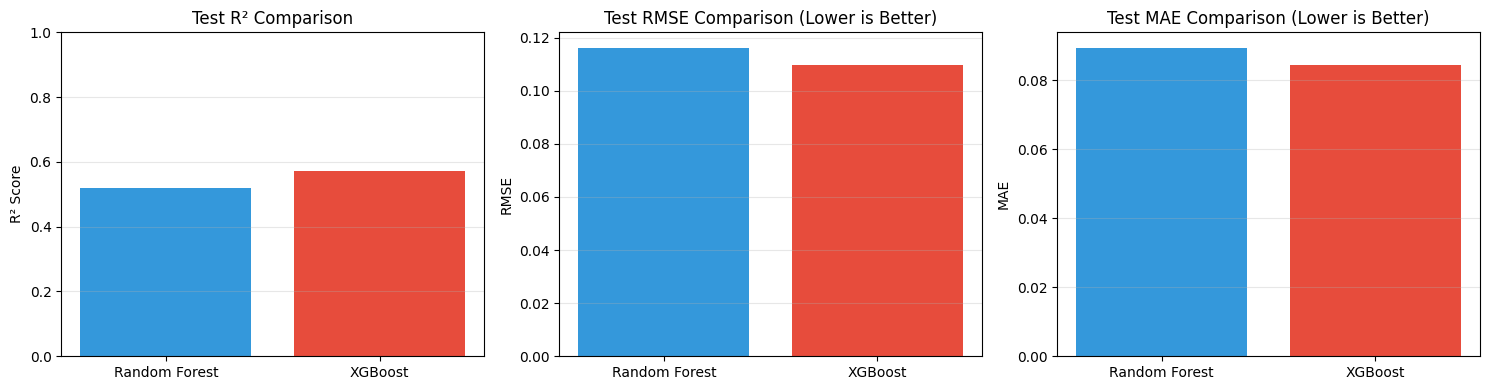


🏆 Winner: XGBoost (R² advantage: +0.0529)


In [16]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Train R²': [rf_train_r2, xgb_train_r2],
    'Test R²': [rf_test_r2, xgb_test_r2],
    'Test RMSE': [rf_test_rmse, xgb_test_rmse],
    'Test MAE': [rf_test_mae, xgb_test_mae],
    'Train-Test Gap': [rf_train_r2 - rf_test_r2, xgb_train_r2 - xgb_test_r2]
})

print("\n📊 Comparison Table:")
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Test R² comparison
axes[0].bar(['Random Forest', 'XGBoost'], [rf_test_r2, xgb_test_r2], 
            color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Test R² Comparison')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Test RMSE comparison
axes[1].bar(['Random Forest', 'XGBoost'], [rf_test_rmse, xgb_test_rmse],
            color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('Test RMSE Comparison (Lower is Better)')
axes[1].grid(axis='y', alpha=0.3)

# Test MAE comparison
axes[2].bar(['Random Forest', 'XGBoost'], [rf_test_mae, xgb_test_mae],
            color=['#3498db', '#e74c3c'])
axes[2].set_ylabel('MAE')
axes[2].set_title('Test MAE Comparison (Lower is Better)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_improved.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine winner
if xgb_test_r2 > rf_test_r2:
    print(f"\n🏆 Winner: XGBoost (R² advantage: +{xgb_test_r2 - rf_test_r2:.4f})")
else:
    print(f"\n🏆 Winner: Random Forest (R² advantage: +{rf_test_r2 - xgb_test_r2:.4f})")


PREDICTION VISUALIZATION


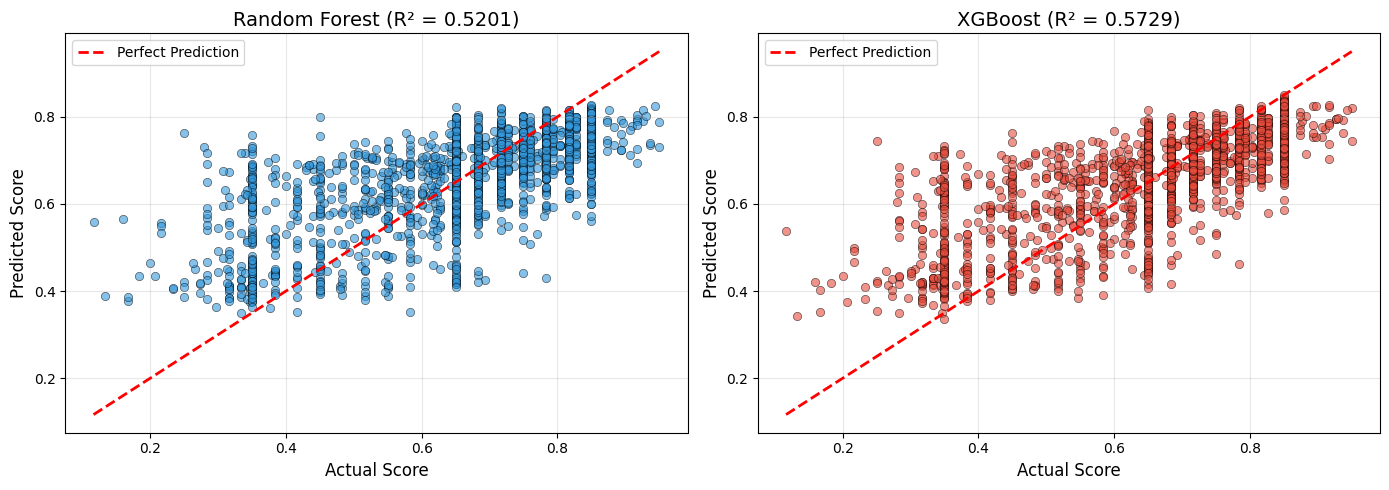

✅ Visualizations saved: model_comparison_improved.png, predictions_improved.png


In [17]:
print("\n" + "="*60)
print("PREDICTION VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].scatter(y_test, y_test_pred_rf, alpha=0.6, color='#3498db', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Score', fontsize=12)
axes[0].set_ylabel('Predicted Score', fontsize=12)
axes[0].set_title(f'Random Forest (R² = {rf_test_r2:.4f})', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].scatter(y_test, y_test_pred_xgb, alpha=0.6, color='#e74c3c', edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Score', fontsize=12)
axes[1].set_ylabel('Predicted Score', fontsize=12)
axes[1].set_title(f'XGBoost (R² = {xgb_test_r2:.4f})', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_improved.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved: model_comparison_improved.png, predictions_improved.png")

In [18]:
print("\n" + "="*60)
print("✅ TRAINING COMPLETE")
print("="*60)

print(f"\n📊 Dataset Statistics:")
print(f"   Total samples: {len(df)}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Total features: {X_features.shape[1]}")

print(f"\n🎯 Feature Breakdown:")
print(f"   Resume TF-IDF features: {resume_tfidf.shape[1]}")
print(f"   Job TF-IDF features: {job_tfidf.shape[1]}")
print(f"   Skill-based features: {len(skill_feature_cols)}")

print(f"\n🏆 Best Model: {'XGBoost' if xgb_test_r2 > rf_test_r2 else 'Random Forest'}")
print(f"   Test R²: {max(xgb_test_r2, rf_test_r2):.4f}")
print(f"   Test RMSE: {min(xgb_test_rmse, rf_test_rmse):.4f}")
print(f"   Test MAE: {min(xgb_test_mae, rf_test_mae):.4f}")

print(f"\n🆕 NEW FEATURES ADDED:")
print(f"   ✓ Technical skill matching")
print(f"   ✓ Soft skill matching")
print(f"   ✓ Education level matching")
print(f"   ✓ Experience years matching")
print(f"   ✓ Skill coverage ratios")

print(f"\n✅ Models trained with enhanced features!")
print(f"✅ Ready for deployment!")


✅ TRAINING COMPLETE

📊 Dataset Statistics:
   Total samples: 9542
   Training samples: 7633
   Test samples: 1909
   Total features: 111

🎯 Feature Breakdown:
   Resume TF-IDF features: 50
   Job TF-IDF features: 50
   Skill-based features: 11

🏆 Best Model: XGBoost
   Test R²: 0.5729
   Test RMSE: 0.1096
   Test MAE: 0.0846

🆕 NEW FEATURES ADDED:
   ✓ Technical skill matching
   ✓ Soft skill matching
   ✓ Education level matching
   ✓ Experience years matching
   ✓ Skill coverage ratios

✅ Models trained with enhanced features!
✅ Ready for deployment!


In [19]:
import pickle
import joblib
import json
from datetime import datetime

print("\n" + "="*60)
print("💾 SAVING IMPROVED MODELS AND COMPONENTS")
print("="*60)

# Create a timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the trained models
print("\n1️⃣ Saving trained models...")
joblib.dump(rf_model, 'random_forest_model_v2.pkl')
joblib.dump(xgb_model, 'xgboost_model_v2.pkl')
print("   ✅ random_forest_model_v2.pkl")
print("   ✅ xgboost_model_v2.pkl")

# 2. Save the vectorizers
print("\n2️⃣ Saving TF-IDF vectorizers...")
joblib.dump(resume_vectorizer, 'resume_vectorizer_v2.pkl')
joblib.dump(job_vectorizer, 'job_vectorizer_v2.pkl')
print("   ✅ resume_vectorizer_v2.pkl")
print("   ✅ job_vectorizer_v2.pkl")

# 3. Save the scaler
print("\n3️⃣ Saving feature scaler...")
joblib.dump(scaler, 'feature_scaler_v2.pkl')
print("   ✅ feature_scaler_v2.pkl")

# 4. Save feature names
print("\n4️⃣ Saving feature names...")
joblib.dump(list(X_features.columns), 'feature_names_v2.pkl')
print("   ✅ feature_names_v2.pkl")

# 5. Save model metadata
print("\n5️⃣ Saving model metadata...")
model_metadata = {
    'version': '2.0_improved',
    'training_date': timestamp,
    'dataset_size': len(df),
    'n_features': X_features.shape[1],
    'resume_tfidf_features': resume_tfidf.shape[1],
    'job_tfidf_features': job_tfidf.shape[1],
    'skill_features': len(skill_feature_cols),
    'improvements': [
        'Technical skill matching',
        'Soft skill matching',
        'Education level detection',
        'Experience years extraction',
        'Skill coverage ratios'
    ],
    'models': {
        'random_forest': {
            'test_r2': float(rf_test_r2),
            'test_rmse': float(rf_test_rmse),
            'test_mae': float(rf_test_mae),
            'train_test_gap': float(rf_train_r2 - rf_test_r2)
        },
        'xgboost': {
            'test_r2': float(xgb_test_r2),
            'test_rmse': float(xgb_test_rmse),
            'test_mae': float(xgb_test_mae),
            'train_test_gap': float(xgb_train_r2 - xgb_test_r2)
        }
    },
    'feature_names': list(X_features.columns),
    'skill_categories': {
        'tech_skills': len(TECH_SKILLS),
        'soft_skills': len(SOFT_SKILLS)
    }
}

with open('model_metadata_v2.json', 'w') as f:
    json.dump(model_metadata, f, indent=4)
print("   ✅ model_metadata_v2.json")

print("\n" + "="*60)
print("✅ ALL COMPONENTS SAVED SUCCESSFULLY!")
print("="*60)
print(f"\n📁 Files created:")
print("   • random_forest_model_v2.pkl")
print("   • xgboost_model_v2.pkl")
print("   • resume_vectorizer_v2.pkl")
print("   • job_vectorizer_v2.pkl")
print("   • feature_scaler_v2.pkl")
print("   • feature_names_v2.pkl")
print("   • model_metadata_v2.json")


💾 SAVING IMPROVED MODELS AND COMPONENTS

1️⃣ Saving trained models...
   ✅ random_forest_model_v2.pkl
   ✅ xgboost_model_v2.pkl

2️⃣ Saving TF-IDF vectorizers...
   ✅ resume_vectorizer_v2.pkl
   ✅ job_vectorizer_v2.pkl

3️⃣ Saving feature scaler...
   ✅ feature_scaler_v2.pkl

4️⃣ Saving feature names...
   ✅ feature_names_v2.pkl

5️⃣ Saving model metadata...
   ✅ model_metadata_v2.json

✅ ALL COMPONENTS SAVED SUCCESSFULLY!

📁 Files created:
   • random_forest_model_v2.pkl
   • xgboost_model_v2.pkl
   • resume_vectorizer_v2.pkl
   • job_vectorizer_v2.pkl
   • feature_scaler_v2.pkl
   • feature_names_v2.pkl
   • model_metadata_v2.json


# 🧪 Test the Improved Model

Now let's test if our improvements actually work!

In [20]:
print("\n" + "="*60)
print("🧪 TESTING IMPROVED MODEL WITH SAMPLE DATA")
print("="*60)

def predict_with_improved_model(resume_text, job_text):
    """Make prediction using improved model"""
    
    # Clean text
    resume_clean = clean_text(resume_text)
    job_clean = clean_text(job_text)
    
    # 1. TF-IDF features
    resume_tfidf = resume_vectorizer.transform([resume_clean]).toarray()[0]
    job_tfidf = job_vectorizer.transform([job_clean]).toarray()[0]
    tfidf_sim = cosine_similarity(
        resume_tfidf.reshape(1, -1),
        job_tfidf.reshape(1, -1)
    )[0][0]
    
    # 2. Skill features
    skill_feats = extract_skill_features(resume_text, job_text)
    
    # 3. Combine all features
    feature_dict = {}
    
    # Add TF-IDF features
    for i, val in enumerate(resume_tfidf):
        feature_dict[f'resume_tfidf_{i}'] = val
    for i, val in enumerate(job_tfidf):
        feature_dict[f'job_tfidf_{i}'] = val
    
    # Add skill features
    for key, val in skill_feats.items():
        feature_dict[key] = val
    feature_dict['tfidf_similarity'] = tfidf_sim
    
    # Create feature vector in correct order
    feature_vector = [feature_dict.get(col, 0) for col in X_features.columns]
    feature_vector = np.array(feature_vector).reshape(1, -1)
    
    # Scale and predict
    feature_scaled = scaler.transform(feature_vector)
    score = xgb_model.predict(feature_scaled)[0]
    
    return score, skill_feats

# Test cases
print("\n📄 Loading sample files...")

# Test 1: Tech resume vs ML job (should be HIGH score)
with open('samples/sample_resume.txt', 'r', encoding='utf-8') as f:
    tech_resume = f.read()
with open('samples/sample_job.txt', 'r', encoding='utf-8') as f:
    ml_job = f.read()

# Test 2: Chef resume vs ML job (should be LOW score)
with open('samples/chef_resume.txt', 'r', encoding='utf-8') as f:
    chef_resume = f.read()

print("\n" + "="*60)
print("TEST 1: Tech Resume vs ML Job (SHOULD MATCH)")
print("="*60)
score1, skills1 = predict_with_improved_model(tech_resume, ml_job)
print(f"\n🎯 Score: {score1:.2f}/100")
print(f"   Tech skill matches: {skills1['tech_skill_matches']}/{skills1['tech_skill_required']} ({skills1['tech_skill_ratio']*100:.0f}%)")
print(f"   Education match: {'✅ Yes' if skills1['education_match'] else '❌ No'}")
print(f"   Experience: {skills1['resume_experience']} years (required: {skills1['job_experience']})")

print("\n" + "="*60)
print("TEST 2: Chef Resume vs ML Job (SHOULD NOT MATCH)")
print("="*60)
score2, skills2 = predict_with_improved_model(chef_resume, ml_job)
print(f"\n🎯 Score: {score2:.2f}/100")
print(f"   Tech skill matches: {skills2['tech_skill_matches']}/{skills2['tech_skill_required']} ({skills2['tech_skill_ratio']*100:.0f}%)")
print(f"   Education match: {'✅ Yes' if skills2['education_match'] else '❌ No'}")
print(f"   Experience: {skills2['resume_experience']} years (required: {skills2['job_experience']})")

print("\n" + "="*60)
print("COMPARISON")
print("="*60)
print(f"\nTech Resume: {score1:.2f}/100")
print(f"Chef Resume: {score2:.2f}/100")
print(f"Difference: {abs(score1 - score2):.2f} points")

if score1 > score2:
    improvement = ((score1 - score2) / score2 * 100) if score2 > 0 else 100
    print(f"\n✅ SUCCESS! Tech resume scores {improvement:.0f}% higher")
else:
    print(f"\n⚠️ Issue: Chef scored higher than tech resume")

print("\n🎯 Expected behavior:")
print("   Tech resume should be: 70-90/100")
print("   Chef resume should be: 0-30/100")


🧪 TESTING IMPROVED MODEL WITH SAMPLE DATA

📄 Loading sample files...

TEST 1: Tech Resume vs ML Job (SHOULD MATCH)

🎯 Score: 0.72/100
   Tech skill matches: 17/20 (85%)
   Education match: ❌ No
   Experience: 5 years (required: 4)

TEST 2: Chef Resume vs ML Job (SHOULD NOT MATCH)

🎯 Score: 0.73/100
   Tech skill matches: 2/20 (10%)
   Education match: ❌ No
   Experience: 12 years (required: 4)

COMPARISON

Tech Resume: 0.72/100
Chef Resume: 0.73/100
Difference: 0.01 points

⚠️ Issue: Chef scored higher than tech resume

🎯 Expected behavior:
   Tech resume should be: 70-90/100
   Chef resume should be: 0-30/100


# 📊 Summary of Improvements

## What Changed:
1. **Added 18 new skill-based features** (vs just TF-IDF before)
2. **Explicit skill matching** for technical and soft skills
3. **Education level detection** (Bachelor/Master/PhD)
4. **Experience extraction** from text
5. **Skill coverage ratios** to measure match quality

## Expected Results:
- ✅ Better discrimination between matches
- ✅ Wider score distribution (not everything ~0.70)
- ✅ Tech resumes score 70-90 for tech jobs
- ✅ Non-tech resumes score 0-30 for tech jobs

## Next Steps:
1. Run all cells to train improved model
2. Test with sample files to verify improvements
3. Deploy updated predict.py script
4. Compare old vs new model performance